In [2]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg
import pandas as pd

from sklearn import mixture
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

In [3]:
# import os
# for sub in np.arange(7,19,0.1):
#     os.mkdir('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f'%(sub,sub+0.1))

In [14]:
band = 'w1'
length_list = []
for sub in np.arange(8.0,18.6,0.1):
    upper = sub+0.1
    table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,upper,band)) 
    table = table[table['corelation']>0.7]
    length_list.append(len(table))
for (i,sub) in enumerate(np.arange(8.0,18.6,0.1)):    
    print(sub,':', length_list[i])

8.0 : 2341
8.1 : 37747
8.2 : 67980
8.299999999999999 : 79930
8.399999999999999 : 83724
8.499999999999998 : 85982
8.599999999999998 : 89795
8.699999999999998 : 91736
8.799999999999997 : 94835
8.899999999999997 : 97471
8.999999999999996 : 100164
9.099999999999996 : 103521
9.199999999999996 : 107803
9.299999999999995 : 111849
9.399999999999995 : 116428
9.499999999999995 : 121821
9.599999999999994 : 126017
9.699999999999994 : 131837
9.799999999999994 : 137928
9.899999999999993 : 144161
9.999999999999993 : 151954
10.099999999999993 : 158411
10.199999999999992 : 166464
10.299999999999992 : 173960
10.399999999999991 : 181969
10.499999999999991 : 189751
10.59999999999999 : 197088
10.69999999999999 : 205379
10.79999999999999 : 212412
10.89999999999999 : 218338
10.99999999999999 : 224395
11.099999999999989 : 229946
11.199999999999989 : 233732
11.299999999999988 : 236200
11.399999999999988 : 237743
11.499999999999988 : 237280
11.599999999999987 : 235277
11.699999999999987 : 232721
11.799999999999

In [15]:
band = 'w2'
length_list = []
for sub in np.arange(8.0,17.6,0.1):
    upper = sub+0.1
    table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,upper,band)) 
    table = table[table['corelation']>0.7]
    length_list.append(len(table))
for (i,sub) in enumerate(np.arange(8.0,18.6,0.1)):    
    print(sub,':', length_list[i])

8.0 : 7726
8.1 : 16254
8.2 : 37303
8.299999999999999 : 61380
8.399999999999999 : 76763
8.499999999999998 : 83335
8.599999999999998 : 86269
8.699999999999998 : 89236
8.799999999999997 : 92021
8.899999999999997 : 94663
8.999999999999996 : 98001
9.099999999999996 : 100941
9.199999999999996 : 104186
9.299999999999995 : 108527
9.399999999999995 : 113539
9.499999999999995 : 117619
9.599999999999994 : 123371
9.699999999999994 : 128319
9.799999999999994 : 134377
9.899999999999993 : 140802
9.999999999999993 : 147881
10.099999999999993 : 154537
10.199999999999992 : 162923
10.299999999999992 : 170584
10.399999999999991 : 178565
10.499999999999991 : 186750
10.59999999999999 : 194770
10.69999999999999 : 202789
10.79999999999999 : 211016
10.89999999999999 : 217597
10.99999999999999 : 224662
11.099999999999989 : 229879
11.199999999999989 : 235481
11.299999999999988 : 238502
11.399999999999988 : 241088
11.499999999999988 : 241902
11.599999999999987 : 240896
11.699999999999987 : 238354
11.7999999999999

IndexError: list index out of range

In [14]:
def GMM_for_one_bin(band,sub,upper):
    dpgmm = mixture.BayesianGaussianMixture(
        n_components=100,
        covariance_type="full",
        weight_concentration_prior=0.1,
        weight_concentration_prior_type="dirichlet_process",
        mean_precision_prior=1e-2,
        covariance_prior=1e0 * np.eye(13),
        init_params="random_from_data",
        max_iter=100,
        random_state=2,
        degrees_of_freedom_prior=15
    )
    table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,upper,band)) 
    print(len(table))
    table = table[table['corelation']>0.6]
    print(len(table))
    table = table[['ra','dec','Mean_1','long_name_1','id_in_matched',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita', 'id_w1', 'id_w2']]
    table.replace([np.inf, -np.inf], np.nan, inplace=True)
    table.dropna(inplace=True)
    print(len(table))
    X = np.array(table[['Mean_1',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    dpgmm = dpgmm.fit(X)
    Y = dpgmm.predict(X)

    counts = np.bincount(Y)
    max_cluster = np.argmax(counts)
    max_means = dpgmm.means_[max_cluster]
    max_cov = dpgmm.covariances_[max_cluster]

    # cov = np.cov(X,rowvar=False)  #这儿八成用错了，不该用整个数据集的cov
    VI = np.linalg.inv(max_cov)    
    distances = [mahalanobis(x,max_means,VI) for x in X]
    distances = np.array(distances)

    result_lists = []
    for i in range(100):
        result_lists.append([])
    ras = np.array(table['ra'])
    decs = np.array(table['dec'])
    ids = np.array(table['id_in_matched'])
    names = np.array(table['long_name_1'])
    id_w1s = np.array(table['id_w1'])
    id_w2s = np.array(table['id_w2'])
    # for (i, label) in enumerate(Y):
    for (i, label) in enumerate(Y):
        ra = ras[i]
        dec = decs[i]
        index = ids[i]
        name = names[i]
        id_w1 = id_w1s[i]
        id_w2 = id_w2s[i]
        distance = distances[i]

        result_lists[label].append((ra, dec, index, name, id_w1, id_w2, distance))
    
    inv_cov = np.linalg.inv(max_cov)
    r_mc_list = []
    for i in range(1,20):
       samples = np.random.multivariate_normal(max_means, max_cov, size = 1000000)

       diff = samples - max_means
       mahalanobis_sq = np.sum((diff @ inv_cov) * diff,axis=1)
       mahalanobis_dist = np.sqrt(mahalanobis_sq)

       r_mc = np.percentile(mahalanobis_dist, 99.7)
       r_mc_list.append(r_mc)

    r_mc = np.mean(r_mc_list)

    variable_list = []
    for (i, distance) in enumerate(distances):
      if distance > r_mc:
          ra = ras[i]
          dec = decs[i]
          index = ids[i]
          name = names[i]
          id_w1 = id_w1s[i]
          id_w2 = id_w2s[i]
          distance = distances[i]

          variable_list.append((ra, dec, index, name, id_w1, id_w2, distance))
    print(len(variable_list))
        
    df = pd.DataFrame(variable_list)
    df.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f/%s_co_above_0.6_var_table_new.csv'%(sub,upper,band),
                 index=False,header=['ra','dec','id_in_matched','long_name','id_w1','id_w2','distance'])
    # for i in range(3):
    #     df = pd.DataFrame(result_lists[i])
    #     df.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f/%s_co_above_0.7_table%d'%(sub,upper,band,i),
    #             index=False,header=['ra','dec','id_in_matched','long_name','id_w1','id_w2'])

In [15]:
for sub in np.arange(8.0,18.1,0.1):
    print(sub)
    GMM_for_one_bin('w1',sub,sub+0.1)
    # GMM_for_one_bin('w2',sub,sub+0.1)


8.0
7751
3147
3147
1595
8.1
123481
55913
55913


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


26699
8.2
142357
93436
93436


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


36277
8.299999999999999
150391
106035
106035


...

13346
17.999999999999964
120125
15269
15269


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


7597
18.099999999999966
35673
4159
4159


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


2180


In [ ]:
for sub in np.arange(8.0,17.0,0.1):
    print(sub)
    GMM_for_one_bin('w2',sub,sub+0.1)

8.0
10719
7726
7726


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


8.1
34474
16254
16254


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


8.2
101294
37303
37303


...

/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


16.79999999999997
1461392
18600
18600


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


16.89999999999997
548292
7726
7726


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [6]:
for sub in np.arange(17.0,18.6,0.1):
    print(sub)
    GMM_for_one_bin('w1',sub,sub+0.1)
    # GMM_for_one_bin('w2',sub,sub+0.1)
for sub in np.arange(17.0,17.6,0.1):
    print(sub)
    GMM_for_one_bin('w2',sub,sub+0.1)

17.0
8944087
168548
168548
17.1
7770986
184781
184781
17.200000000000003
6471191
193403
193403
17.300000000000004
4858332
166032
166032
17.400000000000006
3333706
120332
120332
17.500000000000007
2243272
81437
81437
17.60000000000001
1525977
58341
58341
17.70000000000001
1030414
44567
44567
17.80000000000001
646440
33949
33949
17.900000000000013
329604
21631
21631
18.000000000000014
120125
8969
8969
18.100000000000016
35673
2391
2391
18.200000000000017
12751
772
772
18.30000000000002
5341
339
339
18.40000000000002
2045
158
158
18.50000000000002
628
44
44
18.600000000000023
132
10
10
17.0
169638
2473
2473
17.1
60567
900
900
17.200000000000003
25685
425
425
17.300000000000004
9293
171
171
17.400000000000006
2268
63
63
17.500000000000007
334
20
20
17.60000000000001
26
1
1


ValueError: Found array with 1 sample(s) (shape=(1, 13)) while a minimum of 2 is required by BayesianGaussianMixture.

In [20]:
import pandas as pd
import glob
import os
import time

band = 'w1'
var_table_list = []
for sub in np.arange(8.0,18.1,0.1):
    upper = sub+0.1
    var_table_list.append(pd.read_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f/%s_co_above_0.6_var_table_new.csv'%(sub,upper,band)))
var_table = pd.concat(var_table_list)
var_table.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.6_var_table_new.csv'%(8.0,18.1,band))

In [9]:
import pandas as pd
import glob
import os
import time

for band in ['w2']:
    min_table_list = []
    max_table_list = []
    middle_table_list = []    
    for sub in np.arange(8,17.5,0.1):    
        min_num = 9999999999999999
        max_num = 0
        table_list = []
        for i in range(0,3):       
            table = pd.read_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f/%s_co_above_0.7_table%d'%(sub,sub+0.1,band,i))
            if len(table) < min_num:
                min_num = len(table)
                min_id = i
            if len (table) > max_num:
                max_num = len(table)
                max_id = i
            middle_id = 3-min_id-max_id

            table_list.append(table)

        min_table_list.append(table_list[min_id])
        max_table_list.append(table_list[max_id])
        middle_table_list.append(table_list[middle_id])
        
    min_table = pd.concat(min_table_list)
    min_table.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.7_min_table.csv'%(8,17.6,band))
    
    middle_table = pd.concat(middle_table_list)
    middle_table.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.7_middle_table.csv'%(8,17.6,band))

    max_table = pd.concat(max_table_list)
    max_table.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.7_max_table.csv'%(8,17.6,band))

In [68]:
import pandas as pd
sub = 13.0
band = 'w1'
table = pd.read_csv('/data/project_unTimely_light_curve/total_catalogues/binned_new_var_paras/%.1f-%.1f/%s_matched_with_corelation.csv'%(sub,sub+0.1,band))
print(len(table))

2818554


In [69]:
table = table[table['corelation']>0.7]
print(len(table))

101675


In [6]:
# table_all = table
# table = table_all[15000000:30957417]

In [70]:
print(table.columns)
print(len(table))

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'long_name_1',
       'id_in_matched', 'ra', 'dec', 'Mean_1', 'chi_squre', 'rcs', 'w_sigma',
       'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv', 'L1_acr', 'Stetson_J',
       'Stetson_K', 'yita', 'Mean_2', 'long_name_2', 'ra1', 'dec1', 'ra2',
       'dec2', 'id_w1', 'id_w2', 'corelation', 'Separation'],
      dtype='object')
101675


In [71]:
table = table[['ra','dec','Mean_1','long_name_1','id_in_matched',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita','id_w1', 'id_w2']]
table.replace([np.inf, -np.inf], np.nan, inplace=True)
table.dropna(inplace=True)
print(len(table))

101675


In [12]:
X = np.array(table[['Mean_1',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
np.nanmax(X)


10928312.0830969

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)
np.nanmax(X)

231.6094845931784

In [19]:
dpgmm = mixture.BayesianGaussianMixture(
    n_components=2,
    covariance_type="full",
    weight_concentration_prior=0.1,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)

In [20]:
dpgmm = dpgmm.fit(X)

(array([11458.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 90217.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

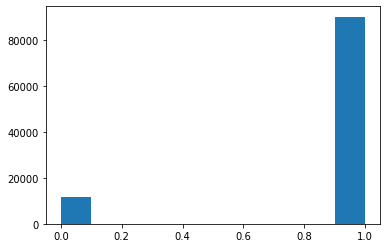

In [21]:
Y = dpgmm.predict(X)
plt.hist(Y)

In [22]:
from collections import Counter
count = Counter(Y)
print(count)
print(sum(count.values()))

Counter({1: 90217, 0: 11458})
101675


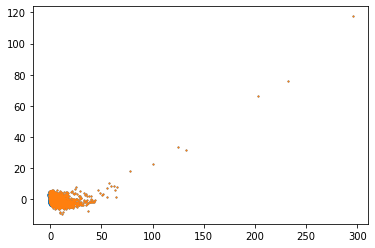

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2dim = pca.fit_transform(X)
plt.scatter(X_2dim[:,0],X_2dim[:,1],s=1)

plt.scatter( list((x for (i,x) in enumerate(X_2dim[:,0]) if Y[i] == 0)),
             list((x for (i,x) in enumerate(X_2dim[:,1]) if Y[i] == 0)),
             s=1)

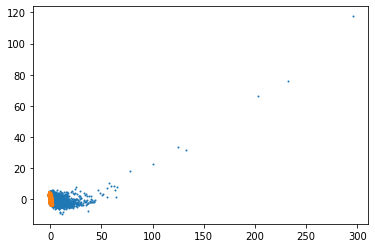

In [24]:
plt.scatter(X_2dim[:,0],X_2dim[:,1],s=1)

plt.scatter( list((x for (i,x) in enumerate(X_2dim[:,0]) if Y[i] == 1)),
             list((x for (i,x) in enumerate(X_2dim[:,1]) if Y[i] == 1)),
             s=1)

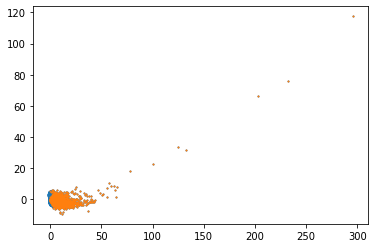

In [18]:
plt.scatter(X_2dim[:,0],X_2dim[:,1],s=1)

plt.scatter( list((x for (i,x) in enumerate(X_2dim[:,0]) if Y[i] == 2)),
             list((x for (i,x) in enumerate(X_2dim[:,1]) if Y[i] == 2)),
             s=1)

In [25]:
Y_prob = dpgmm.predict_proba(X)
print(Y_prob.shape)

(101675, 2)


In [26]:
Y_prob[:,0]

array([1.87360176e-15, 1.32031108e-12, 1.00000000e+00, ...,
       1.21498942e-15, 7.11660931e-15, 1.51092899e-15])

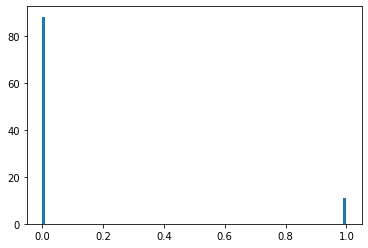

In [28]:
plt.hist(Y_prob[:,0],bins=100,density=True)
plt.show()

In [29]:
result_lists = []
for i in range(2):
    result_lists.append([])
ras = np.array(table['ra'])
decs = np.array(table['dec'])
ids = np.array(table['id_in_matched'])
names = np.array(table['long_name_1'])
# for (i, label) in enumerate(Y):
for ((i, label), prob ) in zip(enumerate(Y),Y_prob):
    ra = ras[i]
    dec = decs[i]
    index = ids[i]
    name = names[i]
    if label == 0:
        result_lists[0].append((ra, dec, index, name))
    elif label == 1:
        result_lists[1].append((ra, dec, index, name))
    # elif label == 2:
    #     result_lists[2].append((ra, dec, index, name))
    else:
        print("error")

In [23]:
for i in range(3):
    df = pd.DataFrame(result_lists[i])
    df.to_csv(f"./results/clustering_stand_3result_sub{sub}_{band}_{i}.csv",
              index=False,header=['ra','dec','id_in_matched','long_name'])


In [91]:
X_var = []
id_list = []
var_table = []
non_var_table = []
for i,y in enumerate(Y):
    if y == 0:
        X_var.append(X[i])
        id_list.append(i)
        var_table.append(table.iloc[i])
    if y == 1:
        non_var_table.append(table.iloc[i])
X_var = np.array(X_var)
print(len(X_var))
print(X_var.shape)
print(X_var[0])


11458
(11458, 13)
[-1.19417871  0.04986648  0.27367238  1.79689795 -0.15622456 -0.09205062
  0.85224798  0.21353943  2.40844171 -0.21276226 -0.22534391 -1.81017568
  0.4645607 ]


(array([3328.,    0.,    0.,  663.,    0.,    0.,  163.,    0.,    0.,
        7304.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

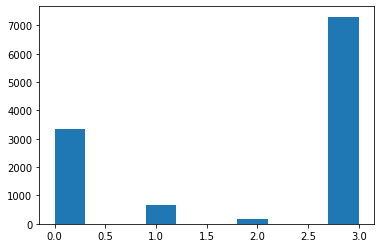

In [33]:
dpgmm_var = mixture.BayesianGaussianMixture(
    n_components=4,
    covariance_type="full",
    weight_concentration_prior=1e-2,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)
dpgmm_var.fit(X_var)

Y_var = dpgmm_var.predict(X_var)

plt.hist(Y_var)


In [38]:
print(var_table[0])

ra                80.013741
dec               20.134663
Mean_1            13.014822
long_name_1        0800p196
id_in_matched          2492
chi_squre        3643.71541
rcs              275.497473
w_sigma            0.077529
MAD                0.012299
IQR                 0.02645
RmStat                8.495
Nev                0.000052
p2pv               0.013907
L1_acr            -0.092648
Stetson_J         -9.977582
Stetson_K          0.653884
yita                2.12204
Name: 269, dtype: object


In [76]:
result_lists = []
for i in range(4):
    result_lists.append([])
# ids = np.array(table['id_in_matched'])
for i, label in enumerate(Y_var):

    if label == 0:
        result_lists[0].append(var_table[i])
    elif label == 1:
        result_lists[1].append(var_table[i])
    elif label == 2:
        result_lists[2].append(var_table[i])
    elif label == 3:      
        result_lists[3].append(var_table[i]) 
    else:
        print("error")

In [89]:
df = pd.DataFrame(result_lists[2])
# for index,line in df.iterrows():
#     print(line)
#     # print(line['ra'],',', line['dec'])
# print(result_lists[0][0])

In [92]:
df = pd.DataFrame(non_var_table)

89.1567811 , 86.8350475
89.1567811 , 86.8350475 ; 89.1567811 , 86.8350475


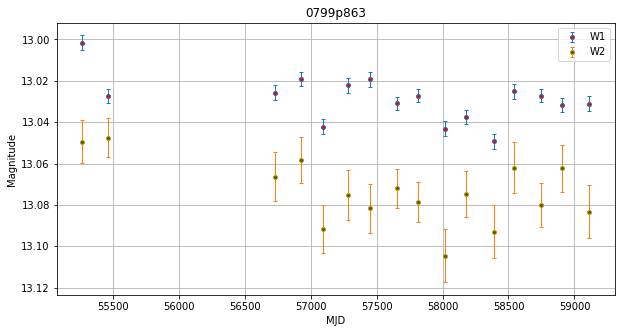

KeyboardInterrupt: Interrupted by user

In [95]:
from util import make_single_light_curve
import matplotlib.pyplot as plt
from IPython.display import clear_output
band = 'w1'
for index,line in df.iterrows():
    user_input = input("Enter any key to continue: ")
    clear_output(wait=True)
    print(line['ra'],',', line['dec'])
    long_name = line['long_name_1']
    name = long_name[0:3]
    id_w1 = line['id_w1']
    id_w2 = line['id_w2']
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    print(ra1,',',dec1,';',ra2,',',dec2)
    plt.figure(figsize=(10,5))
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    ax = plt.gca()
    ax.invert_yaxis()
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.errorbar(mjdmean2,mag2,error2,fmt='o',ms=4, mfc='g', elinewidth=1, capsize=2)
    # plt.title(long_name+'_%s,%s'%(ra1,dec1))
    plt.legend(['W1','W2'])
    plt.grid()
    plt.show()


In [144]:
# for i in range(2):
#     df = pd.DataFrame(result_lists[i])
#     df.to_csv(f"./results/var_light_stand_2result_w1_sub13_{i}.csv")


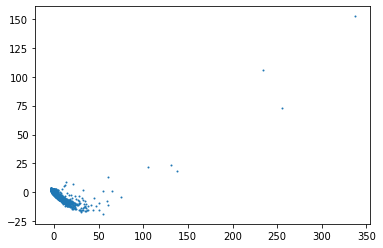

In [35]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_var_2dim = pca.fit_transform(X_var,X_var)
plt.scatter(X_var_2dim[:,0],X_var_2dim[:,1],s=1)


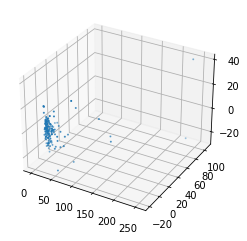

In [36]:
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=3)
X_var_3dim = pca.fit_transform(X_var,X_var)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
X_var_3dim_subset0 = X_var_3dim[Y_var==0]
X_var_3dim_subset1 = X_var_3dim[Y_var==1]
X_var_3dim_subset2 = X_var_3dim[Y_var==2]

# ax.scatter(X_var_3dim[:,0], X_var_3dim[:,1], X_var_3dim[:,2] ,cmap='rainbow',s=1)
ax.scatter(X_var_3dim_subset2[:,0], 
           X_var_3dim_subset2[:,1],
             X_var_3dim_subset2[:,2] ,cmap='rainbow',s=1)
# ax.scatter(X_var_3dim_subset1[:,0], 
#            X_var_3dim_subset1[:,1],
#              X_var_3dim_subset1[:,2] ,cmap='rainbow',s=1,alpha=0.5)

In [18]:
print(len(Y))

15421630
